# Anime(SHOWS) Database OLAP Analysis

> this notebook connects to the `anime_db` PostgreSQL database, explores the star/snowflake schema, runs OLAP queries, and visualizes the results.


## 1. Setup and Connection

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2
from IPython.display import display, Markdown
import graphviz
from sqlalchemy import create_engine

# connection parameters
DB_NAME = "anime_db"
DB_USER = "anime-db0-user"
DB_HOST = "localhost"
DB_PORT = 5432

# create SQLAlchemy engine (for pandas)
engine = create_engine(f'postgresql://{DB_USER}@{DB_HOST}:{DB_PORT}/{DB_NAME}')

# also create a psycopg2 connection for raw queries
conn = psycopg2.connect(
    database=DB_NAME,
    user=DB_USER,
    host=DB_HOST,
    port=DB_PORT
)

print("connected to db - postgres")

connected to db - postgres



## 2. Explore the Schema

list all tables in the `dw` schema.


In [2]:
tables_df = pd.read_sql("""
    SELECT table_name 
    FROM information_schema.tables 
    WHERE table_schema = 'dw'
    ORDER BY table_name;
""", engine)
display(tables_df)

,table_name
0,bridge_anime_genre
1,dim_anime
2,dim_genre
3,dim_time
4,dim_user
5,fact_review
6,v_dim_user_with_age


### 2.1 Show Foreign Key Relationships

In [3]:
fk_query = """
SELECT
    tc.table_name AS source_table,
    kcu.column_name AS source_column,
    ccu.table_name AS target_table,
    ccu.column_name AS target_column
FROM information_schema.table_constraints tc
JOIN information_schema.key_column_usage kcu
    ON tc.constraint_name = kcu.constraint_name
JOIN information_schema.constraint_column_usage ccu
    ON ccu.constraint_name = tc.constraint_name
WHERE tc.constraint_type = 'FOREIGN KEY'
  AND tc.table_schema = 'dw';
"""
fk_df = pd.read_sql(fk_query, engine)
display(fk_df)

,source_table,source_column,target_table,target_column
0,bridge_anime_genre,anime_key,dim_anime,anime_key
1,bridge_anime_genre,genre_key,dim_genre,genre_key
2,fact_review,time_key,dim_time,time_key
3,fact_review,user_key,dim_user,user_key
4,fact_review,anime_key,dim_anime,anime_key


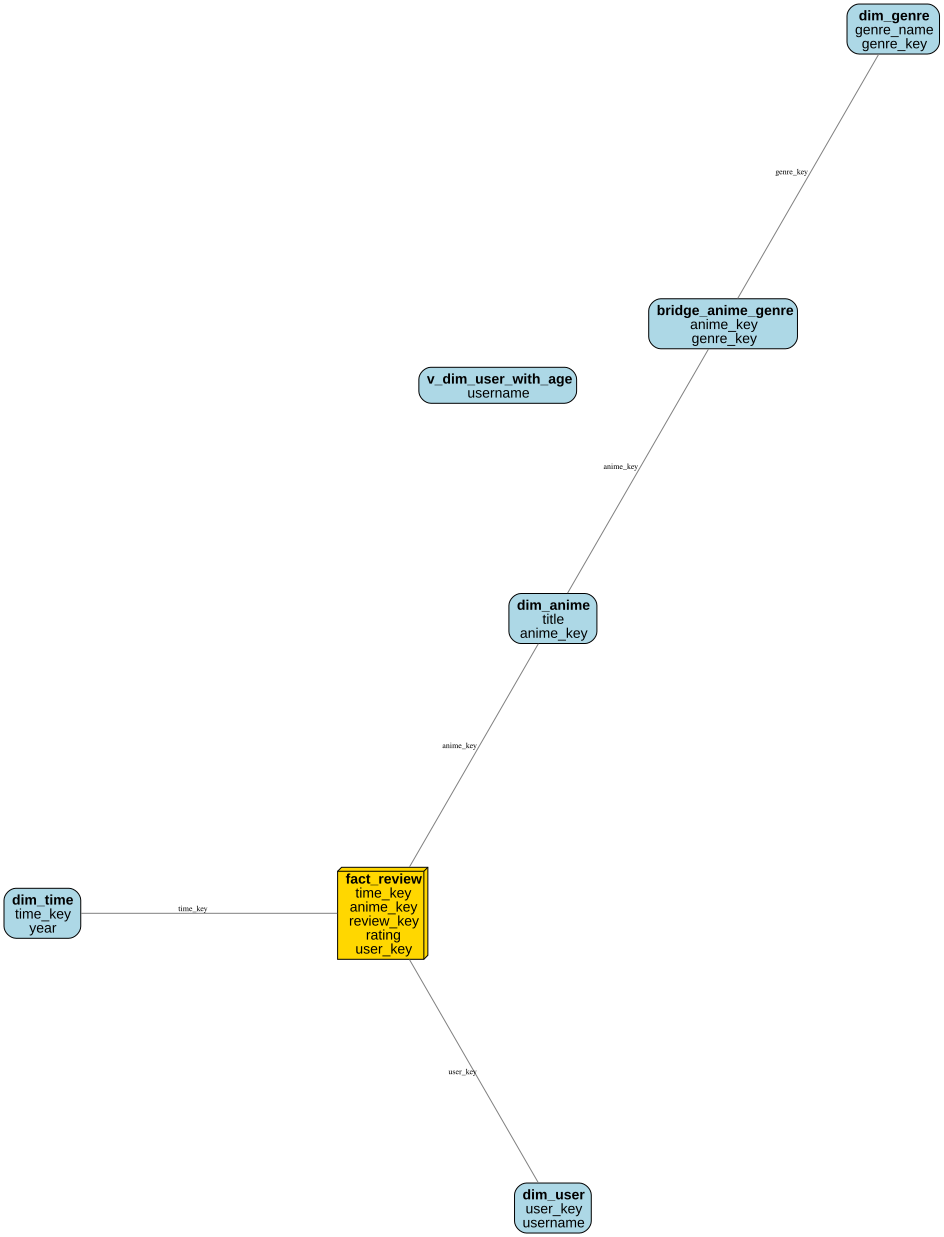

In [4]:
# %%
from IPython.display import SVG
import graphviz
import pandas as pd
from sqlalchemy import create_engine

# connection 
engine = create_engine('postgresql://postgres@localhost:5432/anime_db')

# get foreign key relationships for the dw schema
fk_query = """
SELECT
    tc.table_name AS source_table,
    kcu.column_name AS source_column,
    ccu.table_name AS target_table,
    ccu.column_name AS target_column
FROM information_schema.table_constraints tc
JOIN information_schema.key_column_usage kcu
    ON tc.constraint_name = kcu.constraint_name
JOIN information_schema.constraint_column_usage ccu
    ON ccu.constraint_name = tc.constraint_name
WHERE tc.constraint_type = 'FOREIGN KEY'
  AND tc.table_schema = 'dw';
"""
fk_df = pd.read_sql(fk_query, engine)

# list of tables in dw schema
tables = pd.read_sql("SELECT table_name FROM information_schema.tables WHERE table_schema='dw'", engine)['table_name'].tolist()

# for each table, get a few representative columns (PK, FKs, and a descriptive attribute)
columns = {}
for tbl in tables:
    # get primary key columns
    pk_query = f"""
        SELECT kcu.column_name
        FROM information_schema.table_constraints tc
        JOIN information_schema.key_column_usage kcu
            ON tc.constraint_name = kcu.constraint_name
        WHERE tc.table_schema = 'dw'
          AND tc.table_name = '{tbl}'
          AND tc.constraint_type = 'PRIMARY KEY';
    """
    pk_df = pd.read_sql(pk_query, engine)
    pk_cols = pk_df['column_name'].tolist() if not pk_df.empty else []
    
    # Get foreign key columns (source columns in this table)
    fk_cols = fk_df[fk_df['source_table'] == tbl]['source_column'].tolist()
    
    # Get one descriptive column (e.g., 'title', 'name', 'genre_name', etc.)
    desc_query = f"""
        SELECT column_name
        FROM information_schema.columns
        WHERE table_schema='dw' AND table_name='{tbl}'
          AND column_name IN ('title', 'name', 'genre_name', 'username', 'month_name', 'year', 'rating')
        LIMIT 1;
    """
    desc_df = pd.read_sql(desc_query, engine)
    desc_col = desc_df['column_name'].tolist() if not desc_df.empty else []
    
    # Combine: PKs, FKs, and one descriptive column (unique)
    cols = list(set(pk_cols + fk_cols + desc_col))
    columns[tbl] = cols

# create graph with twopi layout (radial)
dot = graphviz.Graph(engine='twopi', format='svg', comment='Anime Star Schema')
dot.attr(overlap='false', splines='true', root='fact_review')
dot.attr('node', shape='box', style='rounded,filled', fillcolor='lightblue', fontname='Arial')
dot.attr('edge', color='gray', arrowhead='normal')

# add nodes
for tbl in tables:
    if tbl == 'fact_review':
        # Make fact table stand out
        dot.node(tbl, label=f"<<B>{tbl}</B><BR/>{'<BR/>'.join(columns[tbl])}>", 
                 fillcolor='gold', shape='box3d')
    else:
        dot.node(tbl, label=f"<<B>{tbl}</B><BR/>{'<BR/>'.join(columns[tbl])}>")

# add edges for foreign keys (only from fact to dimensions and bridge to dims)
for _, row in fk_df.iterrows():
    dot.edge(row['source_table'], row['target_table'], 
             label=row['source_column'], fontsize='8')

# render and display
dot.render('star_schema_radial', view=False)
SVG('star_schema_radial.svg')

![](./star_schema_radial.svg)

------------------
## 3. OLAP queries

### time series analysis
monthly review trends 
> GROUP BY - simple queries

In [5]:
monthly_query = """
SELECT 
    dt.year,
    dt.month,
    dt.month_name,
    COUNT(fr.review_key) AS review_count,
    AVG(fr.rating) AS avg_rating
FROM dw.fact_review fr
JOIN dw.dim_time dt ON fr.time_key = dt.time_key
GROUP BY dt.year, dt.month, dt.month_name
ORDER BY dt.year, dt.month;
"""
monthly_df = pd.read_sql(monthly_query, engine)
display(monthly_df.head(10))

,year,month,month_name,review_count,avg_rating
0,2023,2,February,8,6.375000
1,2023,3,March,30,5.366667
2,2023,4,April,28,5.321429
3,2023,5,May,44,5.704545
4,2023,6,June,30,5.233333
5,2023,7,July,37,4.756757
6,2023,8,August,34,5.823529
7,2023,9,September,36,5.583333
8,2023,10,October,32,5.812500
9,2023,11,November,32,5.250000


In [6]:
top_anime_query = """
SELECT 
    da.title,
    COUNT(fr.review_key) AS review_count,
    AVG(fr.rating) AS avg_rating
FROM dw.fact_review fr
JOIN dw.dim_anime da ON fr.anime_key = da.anime_key
GROUP BY da.anime_key, da.title
HAVING COUNT(fr.review_key) >= 10
ORDER BY avg_rating DESC
LIMIT 10;
"""
top_anime_df = pd.read_sql(top_anime_query, engine)
display(top_anime_df)

,title,review_count,avg_rating
0,Persevering holistic artificial intelligence,46,6.260870
1,Assimilated solution-oriented open system,46,6.108696
2,Multi-channeled national customer loyalty,52,5.942308
3,Customer-focused stable middleware,55,5.927273
4,Intuitive executive application,35,5.885714
5,Robust asynchronous budgetary management,60,5.850000
6,Cloned global matrices,50,5.840000
7,Organized asynchronous archive,49,5.755102
8,Naruto,44,5.590909
9,Naruto Shippuden,47,5.553191


In [7]:
rating_dist_query = """
SELECT rating, COUNT(*) AS frequency
FROM dw.fact_review
GROUP BY rating
ORDER BY rating;
"""
rating_dist_df = pd.read_sql(rating_dist_query, engine)
display(rating_dist_df)

# genre popularity (top 10 by review count)

# %%
genre_pop_query = """
SELECT 
    dg.genre_name,
    COUNT(fr.review_key) AS review_count
FROM dw.fact_review fr
JOIN dw.bridge_anime_genre bag ON fr.anime_key = bag.anime_key
JOIN dw.dim_genre dg ON bag.genre_key = dg.genre_key
GROUP BY dg.genre_name
ORDER BY review_count DESC
LIMIT 10;
"""
genre_pop_df = pd.read_sql(genre_pop_query, engine)
display(genre_pop_df)

,rating,frequency
0,1,134
1,2,108
2,3,111
3,4,130
4,5,113
5,6,107
6,7,133
7,8,131
8,9,111
9,10,113


,genre_name,review_count
0,Adventure,413
1,Action,348
2,Fantasy,335
3,Drama,306
4,Romance,299
5,Comedy,248
6,Sci-Fi,235
7,Horror,189
8,Slice of Life,157


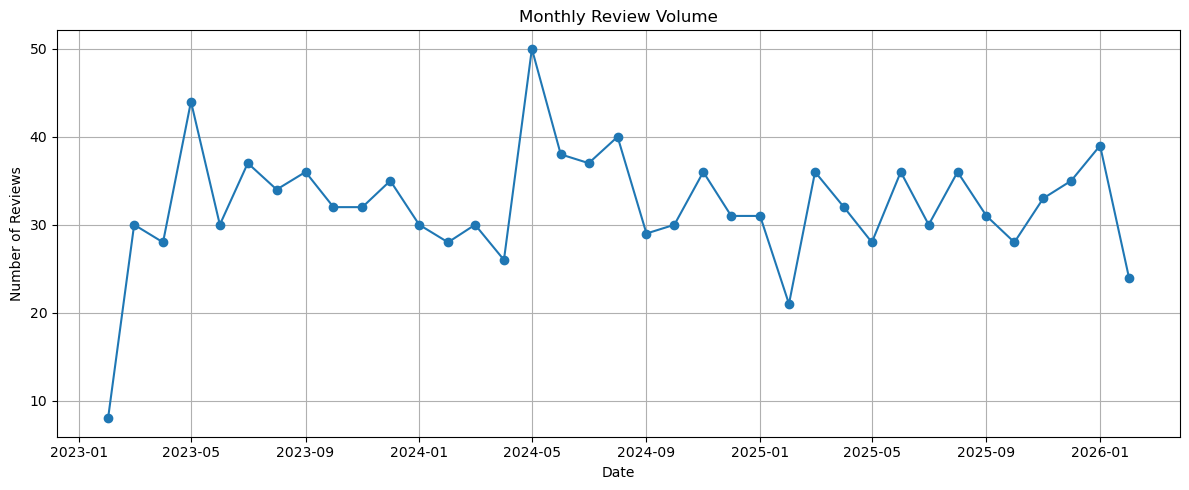

In [8]:
monthly_df['date'] = pd.to_datetime(monthly_df['year'].astype(str) + '-' + monthly_df['month'].astype(str) + '-01')
plt.figure(figsize=(12,5))
plt.plot(monthly_df['date'], monthly_df['review_count'], marker='o')
plt.title('Monthly Review Volume')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.grid(True)
plt.tight_layout()
plt.show()

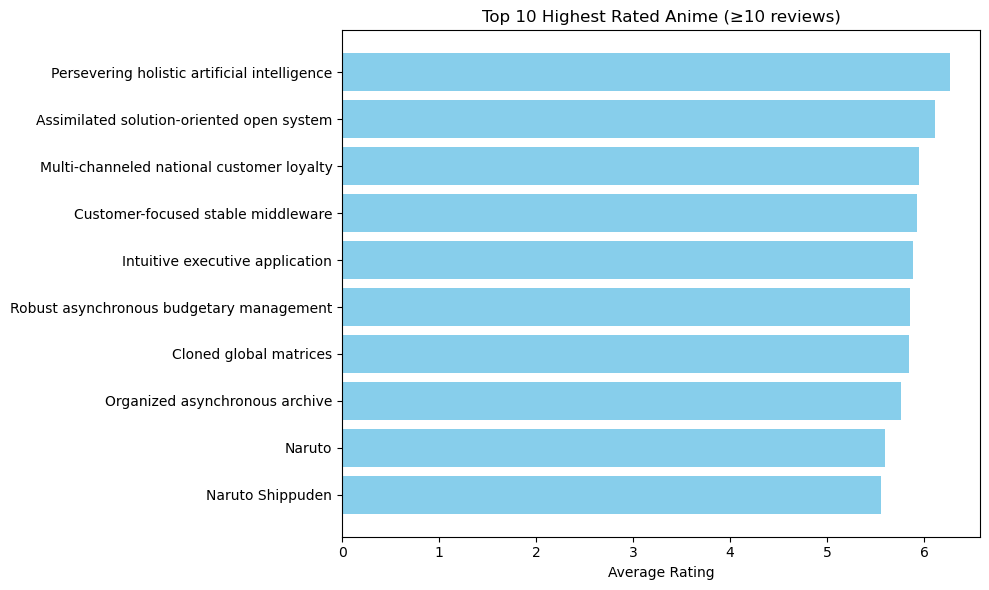

In [9]:
plt.figure(figsize=(10,6))
plt.barh(top_anime_df['title'], top_anime_df['avg_rating'], color='skyblue')
plt.xlabel('Average Rating')
plt.title('Top 10 Highest Rated Anime (≥10 reviews)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


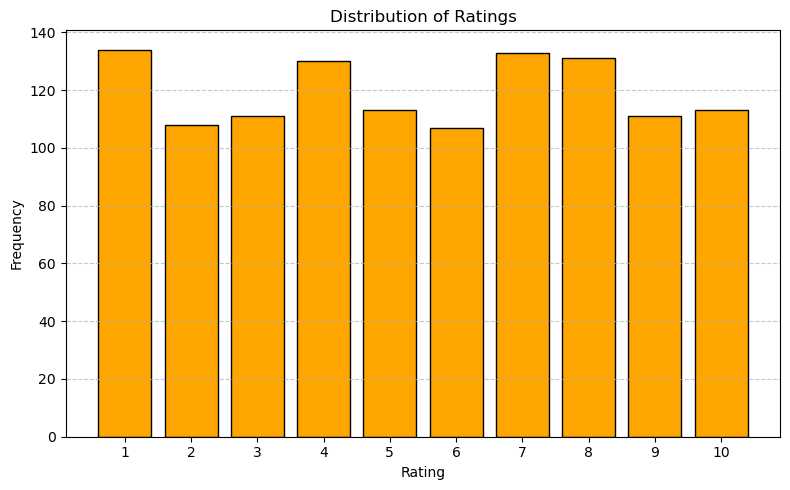

In [10]:
plt.figure(figsize=(8,5))
plt.bar(rating_dist_df['rating'], rating_dist_df['frequency'], color='orange', edgecolor='black')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.title('Distribution of Ratings')
plt.xticks(range(1,11))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

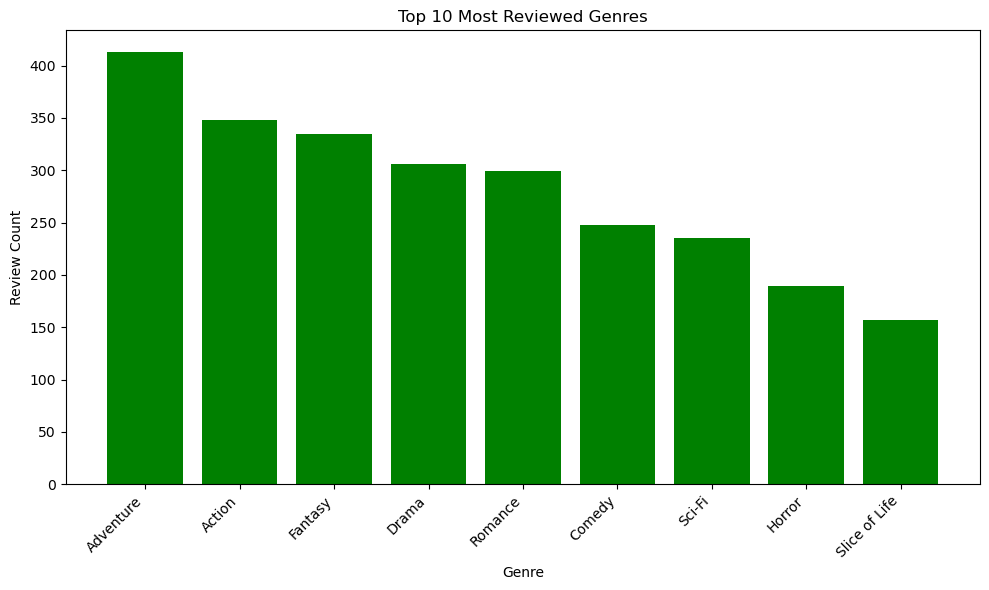

In [11]:
plt.figure(figsize=(10,6))
plt.bar(genre_pop_df['genre_name'], genre_pop_df['review_count'], color='green')
plt.xlabel('Genre')
plt.ylabel('Review Count')
plt.title('Top 10 Most Reviewed Genres')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. OLAP operations: ROLLUP and CUBE

>**INFO**: in this context subtotals and grand totals are done automatically.

### 4.1 ROLLUP - for hierarchical aggregation

`ROLLUP` creates subtotals at each level of the hierarchy e.g. (year → month → grand total).

**SALIENT:** automatic generation of subtotals for each grouping level.

In [12]:
# ROLLUP - average rating and review count by year and month with subtotals
rollup_query = """
SELECT 
    dt.year,
    dt.month,
    dt.month_name,
    COUNT(fr.review_key) AS review_count,
    ROUND(AVG(fr.rating)::numeric, 2) AS avg_rating
FROM dw.fact_review fr
JOIN dw.dim_time dt ON fr.time_key = dt.time_key
GROUP BY ROLLUP(dt.year, dt.month, dt.month_name)
ORDER BY dt.year NULLS LAST, dt.month NULLS LAST
LIMIT 50;
"""
rollup_df = pd.read_sql(rollup_query, engine)
display(rollup_df)

# # Highlight the subtotals
# print("\nNote: Rows with NULL in 'month' and 'month_name' are yearly subtotals.")
# print("The final row with NULL in all columns is the grand total.")

,year,month,month_name,review_count,avg_rating
0,2023,2.0,None,8,6.38
1,2023,2.0,February,8,6.38
2,2023,3.0,March,30,5.37
3,2023,3.0,None,30,5.37
4,2023,4.0,None,28,5.32
5,2023,4.0,April,28,5.32
6,2023,5.0,May,44,5.70
7,2023,5.0,None,44,5.70
8,2023,6.0,None,30,5.23
9,2023,6.0,June,30,5.23


### 4.2 CUBE - for multidimensional analysis

CUBE generates all possible combinations of groupings (anime × user join year, plus all subtotals).

**SALIENT:** makes a 2^n grouping combination where n is the number of dimensions.

In [13]:
# CUBE - analyze by anime title and user join year (all combinations)
cube_query = """
SELECT 
    da.title,
    du.join_year,
    COUNT(fr.review_key) AS review_count,
    ROUND(AVG(fr.rating)::numeric, 2) AS avg_rating
FROM dw.fact_review fr
JOIN dw.dim_anime da ON fr.anime_key = da.anime_key
JOIN dw.dim_user du ON fr.user_key = du.user_key
GROUP BY CUBE(da.title, du.join_year)
HAVING COUNT(fr.review_key) >= 5  -- Filter for readability
ORDER BY da.title NULLS LAST, du.join_year NULLS LAST
LIMIT 100;
"""
cube_df = pd.read_sql(cube_query, engine)
display(cube_df.head(20))

# print("\nNote: CUBE generates 4 types of aggregations:")
# print("1. Both dimensions specified: rating for specific anime by specific cohort")
# print("2. Only title NULL: rating for each join year across all anime")
# print("3. Only join_year NULL: rating for each anime across all cohorts")
# print("4. Both NULL: grand total across all anime and cohorts")

,title,join_year,review_count,avg_rating
0,Assimilated solution-oriented open system,2021.0,7,6.57
1,Assimilated solution-oriented open system,2022.0,12,6.83
2,Assimilated solution-oriented open system,2023.0,5,4.40
3,Assimilated solution-oriented open system,2024.0,8,6.25
4,Assimilated solution-oriented open system,2025.0,14,5.79
5,Assimilated solution-oriented open system,NaN,46,6.11
6,Attack on Titan,2021.0,13,5.15
7,Attack on Titan,2022.0,6,5.17
8,Attack on Titan,2023.0,8,4.88
9,Attack on Titan,2024.0,9,3.89


------------
### VISUALIZATIONS FOR INSIGHTS/DECISION MAKING

### 4.3 visualize CUBE

for multidimensional analysis from CUBE operation.

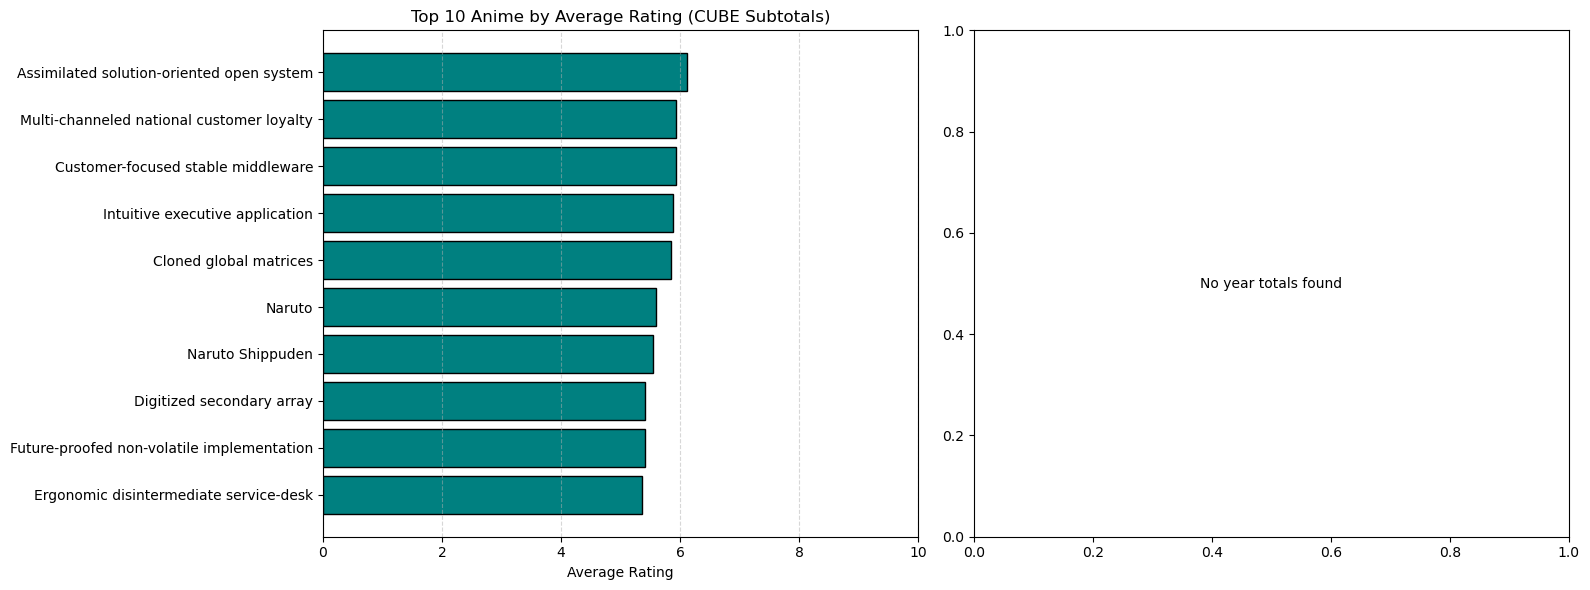

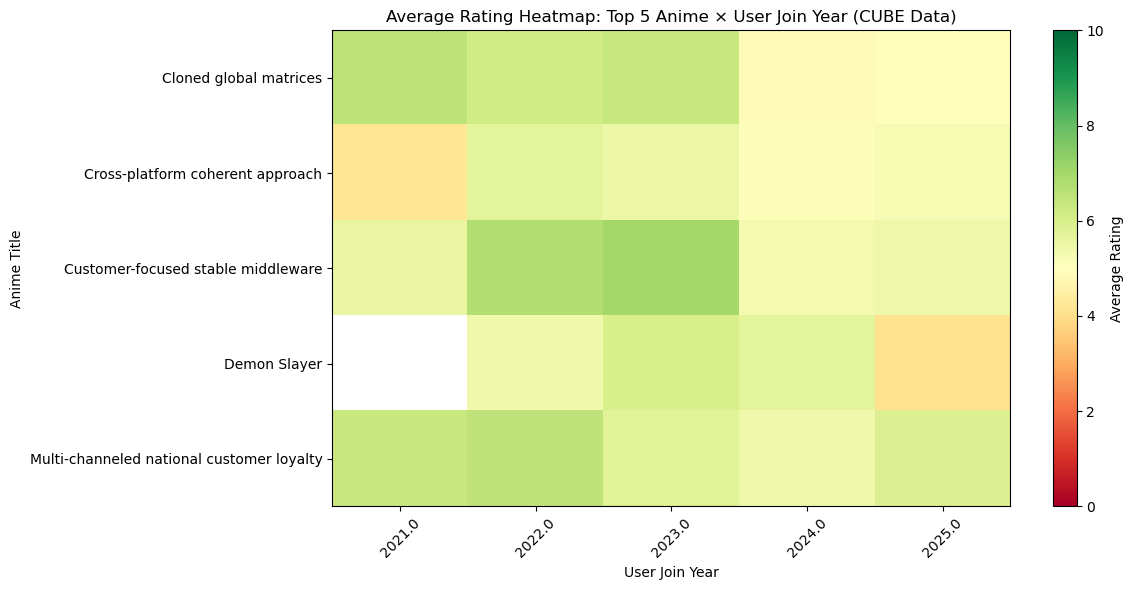

In [14]:
# data for visualization - exclude grand totals (where both are NULL)
# get rows where both dimensions are specified (not NULL)
detailed_cube = cube_df[(cube_df['title'].notna()) & (cube_df['join_year'].notna())].copy()

# get anime totals (title specified, join_year is NULL)
anime_totals = cube_df[(cube_df['title'].notna()) & (cube_df['join_year'].isna())].copy()

if not detailed_cube.empty and not anime_totals.empty:
    # Plot 1: Top anime by average rating (from CUBE totals)
    top_anime = anime_totals.nlargest(10, 'avg_rating')
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # visualization 1: top anime average ratings (CUBE subtotals)
    ax1.barh(top_anime['title'], top_anime['avg_rating'], color='teal', edgecolor='black')
    ax1.set_xlabel('Average Rating')
    ax1.set_title('Top 10 Anime by Average Rating (CUBE Subtotals)')
    ax1.set_xlim([0, 10])
    ax1.invert_yaxis()
    ax1.grid(axis='x', linestyle='--', alpha=0.5)
    
    # Visualization 2: Review count by join year (CUBE subtotals - year dimension)
    year_totals = cube_df[(cube_df['title'].isna()) & (cube_df['join_year'].notna())].copy()
    if not year_totals.empty:
        year_totals = year_totals.sort_values('join_year')
        ax2.plot(year_totals['join_year'], year_totals['review_count'], 
                marker='o', color='purple', linewidth=2, markersize=8)
        ax2.set_xlabel('User Join Year')
        ax2.set_ylabel('Total Reviews')
        ax2.set_title('Total Reviews by User Cohort (CUBE Subtotals)')
        ax2.grid(True, linestyle='--', alpha=0.5)
    else:
        ax2.text(0.5, 0.5, 'No year totals found', ha='center', va='center')
    
    plt.tight_layout()
    plt.show()
    
    # heatmap-style view of specific combinations
    # select top 5 anime for detailed view
    top_5_anime = anime_totals.nlargest(5, 'review_count')['title'].tolist()
    heatmap_data = detailed_cube[detailed_cube['title'].isin(top_5_anime)].copy()
    
    if not heatmap_data.empty:
        # pivot for heatmap
        pivot_ratings = heatmap_data.pivot_table(
            index='title', 
            columns='join_year', 
            values='avg_rating', 
            aggfunc='first'
        )
        
        plt.figure(figsize=(12, 6))
        plt.imshow(pivot_ratings.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=10)
        plt.colorbar(label='Average Rating')
        plt.yticks(range(len(pivot_ratings.index)), pivot_ratings.index)
        plt.xticks(range(len(pivot_ratings.columns)), pivot_ratings.columns, rotation=45)
        plt.xlabel('User Join Year')
        plt.ylabel('Anime Title')
        plt.title('Average Rating Heatmap: Top 5 Anime × User Join Year (CUBE Data)')
        plt.tight_layout()
        plt.show()
else:
    print("Insufficient data for CUBE visualization.")

### 4.4 Visualize ROLLUP

extract and visualize yearly trends from ROLLUP operation.

2 yearly subtotals from ROLLUP operation



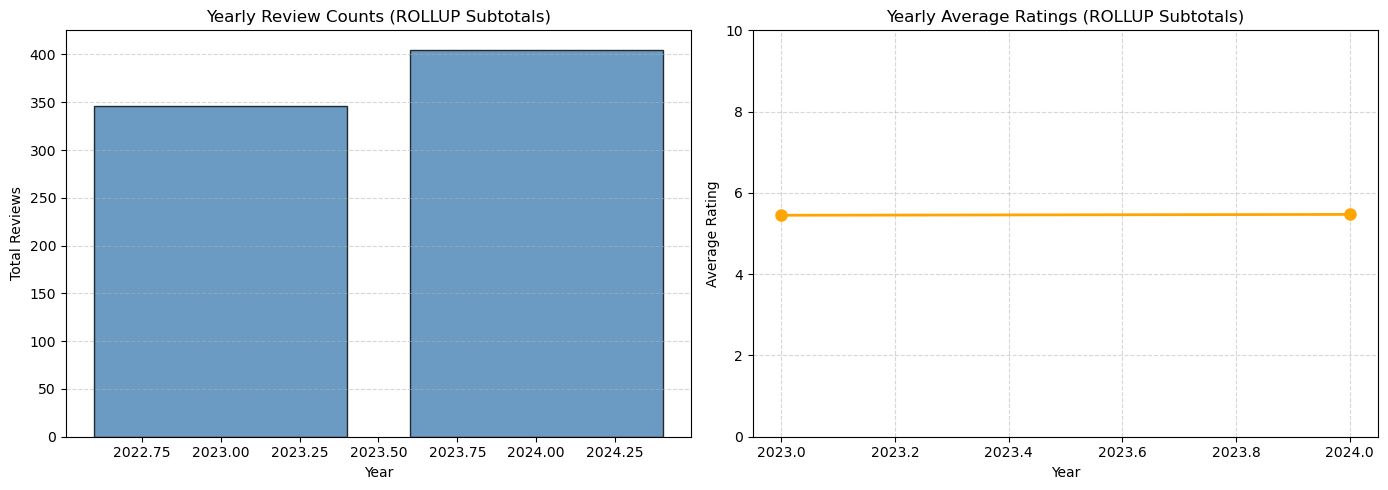

In [15]:
# yearly subtotals from ROLLUP (where month is NULL but year is not)
yearly_subtotals = rollup_df[(rollup_df['month'].isna()) & (rollup_df['year'].notna())].copy()

if not yearly_subtotals.empty:
    print(f"{len(yearly_subtotals)} yearly subtotals from ROLLUP operation\n")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # plot 1: yearly review counts
    ax1.bar(yearly_subtotals['year'], yearly_subtotals['review_count'], 
            color='steelblue', edgecolor='black', alpha=0.8)
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Total Reviews')
    ax1.set_title('Yearly Review Counts (ROLLUP Subtotals)')
    ax1.grid(axis='y', linestyle='--', alpha=0.5)

    # plot 2: yearly average ratings
    ax2.plot(yearly_subtotals['year'], yearly_subtotals['avg_rating'], 
            marker='o', color='orange', linewidth=2, markersize=8)
    ax2.set_xlabel('Year')
    ax2.set_ylabel('Average Rating')
    ax2.set_title('Yearly Average Ratings (ROLLUP Subtotals)')
    ax2.set_ylim([0, 10])
    ax2.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    # show grand total if it exists
    grand_total = rollup_df[(rollup_df['year'].isna()) & (rollup_df['month'].isna())]
    if not grand_total.empty:
        print(f"\nGrand Total from ROLLUP:")
        print(f"  Total Reviews: {grand_total['review_count'].values[0]:,}")
        print(f"  Overall Average Rating: {grand_total['avg_rating'].values[0]}")
else:
    print("No yearly subtotals found in ROLLUP results")

#### end